In [68]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [69]:
data = pd.read_csv("classData.csv")

In [70]:
fault_cols = ['G', 'C', 'B', 'A']

In [71]:
label_map = {
    '0000': 'No Fault',
    '1001': 'LG fault (Between phase A and Gnd)',
    '0110': 'LL fault (Between phase A and phase B)',
    '1011': 'LLG fault (Between phases A,B and Gnd)',
    '0111': 'LLL fault (Between all three phases)',
    '1111': 'LLLG fault (Three phase symmetrical fault)'
}

In [72]:
data['fault_label'] = (data[fault_cols]
                     .astype(str)
                     .agg(''.join, axis=1)
                     .map(label_map))

In [73]:
X = data.drop(columns=fault_cols + ['fault_label'])
le = LabelEncoder()
Y = le.fit_transform(data['fault_label'])
class_names = le.classes_

In [74]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

In [77]:
# Model 1 — default
rf_default = RandomForestClassifier(n_estimators=100, random_state=42)
rf_default.fit(X_train, Y_train)
Y_pred_default = rf_default.predict(X_test)


In [78]:
# Model 2 — balanced
rf_balanced = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42
)
rf_balanced.fit(X_train, Y_train)
Y_pred_balanced = rf_balanced.predict(X_test)


In [79]:
cm = confusion_matrix(Y_test, Y_pred_default)

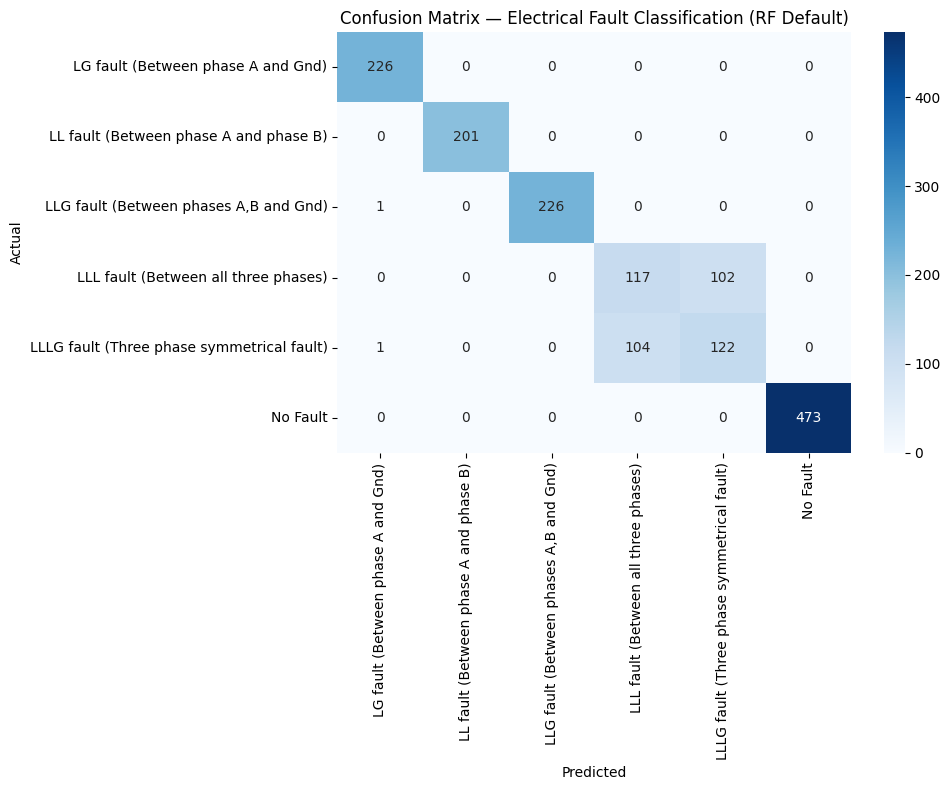

In [80]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Electrical Fault Classification (RF Default)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [81]:
# Classification reports — compare both models
print("=" * 55)
print("DEFAULT (no balancing)")
print("=" * 55)
print(classification_report(Y_test, Y_pred_default,
      target_names=class_names))

print("=" * 55)
print("BALANCED (class_weight='balanced')")
print("=" * 55)
print(classification_report(Y_test, Y_pred_balanced,
      target_names=class_names))

DEFAULT (no balancing)
                                            precision    recall  f1-score   support

        LG fault (Between phase A and Gnd)       0.99      1.00      1.00       226
    LL fault (Between phase A and phase B)       1.00      1.00      1.00       201
    LLG fault (Between phases A,B and Gnd)       1.00      1.00      1.00       227
      LLL fault (Between all three phases)       0.53      0.53      0.53       219
LLLG fault (Three phase symmetrical fault)       0.54      0.54      0.54       227
                                  No Fault       1.00      1.00      1.00       473

                                  accuracy                           0.87      1573
                                 macro avg       0.84      0.84      0.84      1573
                              weighted avg       0.87      0.87      0.87      1573

BALANCED (class_weight='balanced')
                                            precision    recall  f1-score   support

        LG fau